# Análisis Exploratorio de Redes Sociales y Resultados Electorales

Este notebook realiza un análisis integrando los datos unificados de Facebook, TikTok y Twitter con los resultados electorales oficiales.

## **1. Análisis por interacciones totales**

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

# Definición de rutas
base_path = os.getcwd()
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')

c:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Carga de Datos

In [2]:
# Cargar datos de redes sociales
df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')

# Cargar datos electorales
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

print(f"Redes: {df_redes.shape}")
print(f"Electoral: {df_electoral.shape}")

Redes: (5871, 18)
Electoral: (350, 9)


## 2. Integración de Datos (Merge)

In [3]:
# Combinar ambos datasets
df_completo = pd.merge(
    df_redes, 
    df_electoral[['id_candidato', 'Candidato', 'Ganador', 'Votos']], 
    on='id_candidato', 
    how='left'
)

# Calcular métrica de interacciones totales por post
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

df_completo.head()

,id_candidato,red_social,fecha,hora,usuario,texto,url,likes,comentarios,compartidos,...,fb_haha,fb_care,fb_wow,fb_sad,fb_angry,favoritos,Candidato,Ganador,Votos,interacciones_totales
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,506,5,2,...,3,0,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,513
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,1581,178,84,...,294,10,2,1,1,0,Albert Yordano Corredor Bustamante,No,27261,1843
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,485,9,2,...,5,1,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,496
3,COL-05001-010,Facebook,2023-10-28,14:03:34,albertyordanocorredor,"Aquí no hay solamente equipo de trabajo, aquí ...",https://www.facebook.com/reel/889427628897103/,447,5,5,...,0,1,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,457
4,COL-05001-010,Facebook,2023-10-28,12:00:47,albertyordanocorredor,Cuando mis hijos preguntan por qué estamos tra...,https://www.facebook.com/albertyordanocorredor...,529,8,2,...,1,3,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,539


## 3. Análisis por Candidato
¿Quiénes tienen mayor tracción en redes?

...¿Y por red social? 

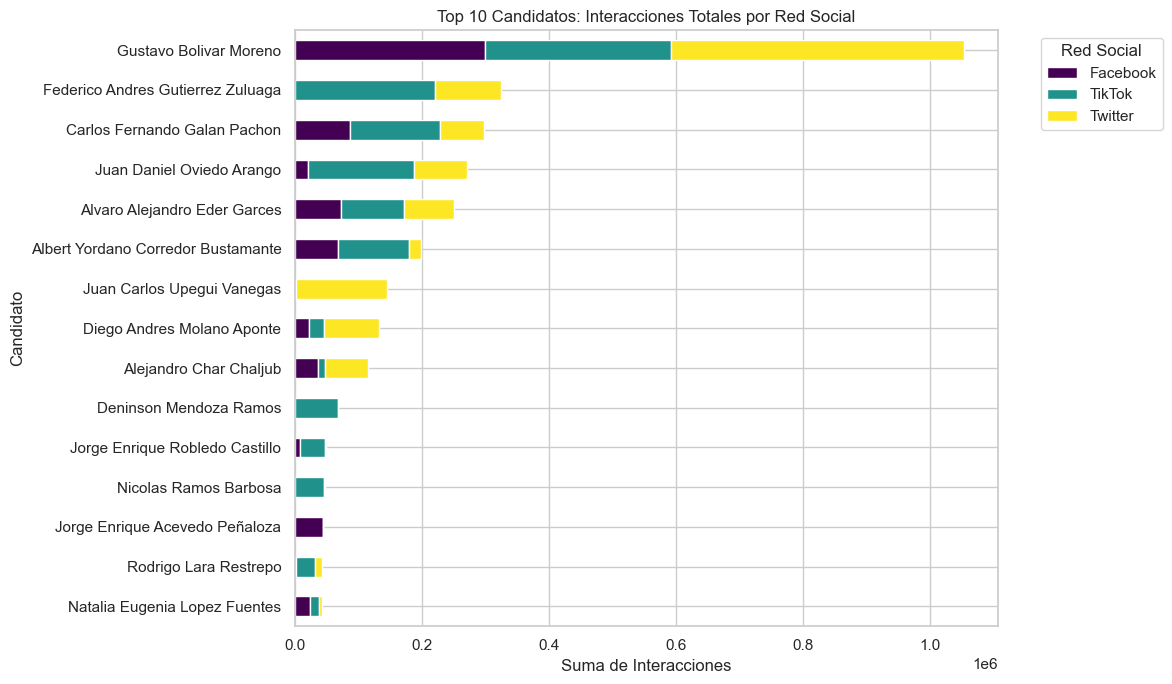

In [4]:
top_nombres = df_completo.groupby('Candidato')['interacciones_totales'].sum().sort_values(ascending=False).head(15).index
df_top = df_completo[df_completo['Candidato'].isin(top_nombres)]
grafico_data = df_top.groupby(['Candidato', 'red_social'])['interacciones_totales'].sum().unstack().fillna(0)
grafico_data = grafico_data.loc[top_nombres]
grafico_data.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Top 10 Candidatos: Interacciones Totales por Red Social')
plt.xlabel('Suma de Interacciones')
plt.ylabel('Candidato')
plt.gca().invert_yaxis()
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Análisis por Red Social
Interacciones promedio por publicación.

In [5]:
promedio_red = df_completo.groupby('red_social')[['likes', 'comentarios', 'compartidos', 'vistas']].mean().round(2)
promedio_red

,likes,comentarios,compartidos,vistas
red_social,,,,
Facebook,392.21,76.11,72.55,9144.64
TikTok,1246.22,59.92,54.68,26154.48
Twitter,338.49,58.02,120.08,16946.03


## 5. Relación entre Interacciones y Éxito Electoral
¿Los ganadores tienen mejores métricas?

In [6]:
# Agrupación por persona
stats_candidato = df_completo.groupby(['id_candidato', 'Candidato', 'Ganador']).agg({
    'interacciones_totales': 'sum',
    'id_candidato': 'count', # num publicaciones
    'Votos': 'first'
}).rename(columns={'id_candidato': 'num_posts'}).reset_index()

stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# Comparativa Ganadores vs No Ganadores
stats_candidato.groupby('Ganador')[['interacciones_totales', 'interacciones_promedio', 'num_posts', 'Votos']].mean().round(2)

,interacciones_totales,interacciones_promedio,num_posts,Votos
Ganador,,,,
No,28008.00,370.11,45.57,43947.68
Sí,42740.97,756.31,51.03,150613.19


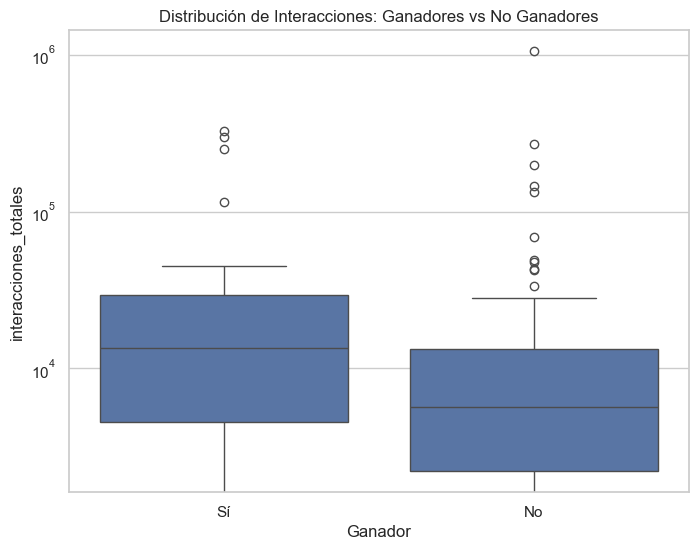

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_totales', data=stats_candidato)
plt.title('Distribución de Interacciones: Ganadores vs No Ganadores')
plt.yscale('log') # Escala logarítmica para mejor visualización
plt.show()

In [8]:
from scipy.stats import mannwhitneyu

# 1. Separar los grupos
ganadores = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_totales']
no_ganadores = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_totales']

# 2. Ejecutar la prueba de Mann-Whitney U
stat, p_value = mannwhitneyu(ganadores, no_ganadores, alternative='two-sided')

# 3. Mostrar resultados
print(f"Estadístico U: {stat}")
print(f"P-Valor: {p_value:.4f}")

# 4. Interpretación científica
alpha = 0.10
if p_value < alpha:
    print("\n CONCLUSIÓN: La diferencia ES estadísticamente significativa.")
    print("Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.")
else:
    print("\n❌ CONCLUSIÓN: La diferencia NO es estadísticamente significativa.")
    print("A pesar de los promedios, no podemos decir que los ganadores tengan consistentemente más interacciones que los perdedores.")

# 5. Ver medianas (son más confiables que los promedios en este caso)
print(f"\nMediana Ganadores: {ganadores.median()}")
print(f"Mediana No Ganadores: {no_ganadores.median()}")


Estadístico U: 1903.5
P-Valor: 0.0189

 CONCLUSIÓN: La diferencia ES estadísticamente significativa.
Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.

Mediana Ganadores: 13477.5
Mediana No Ganadores: 5620.0


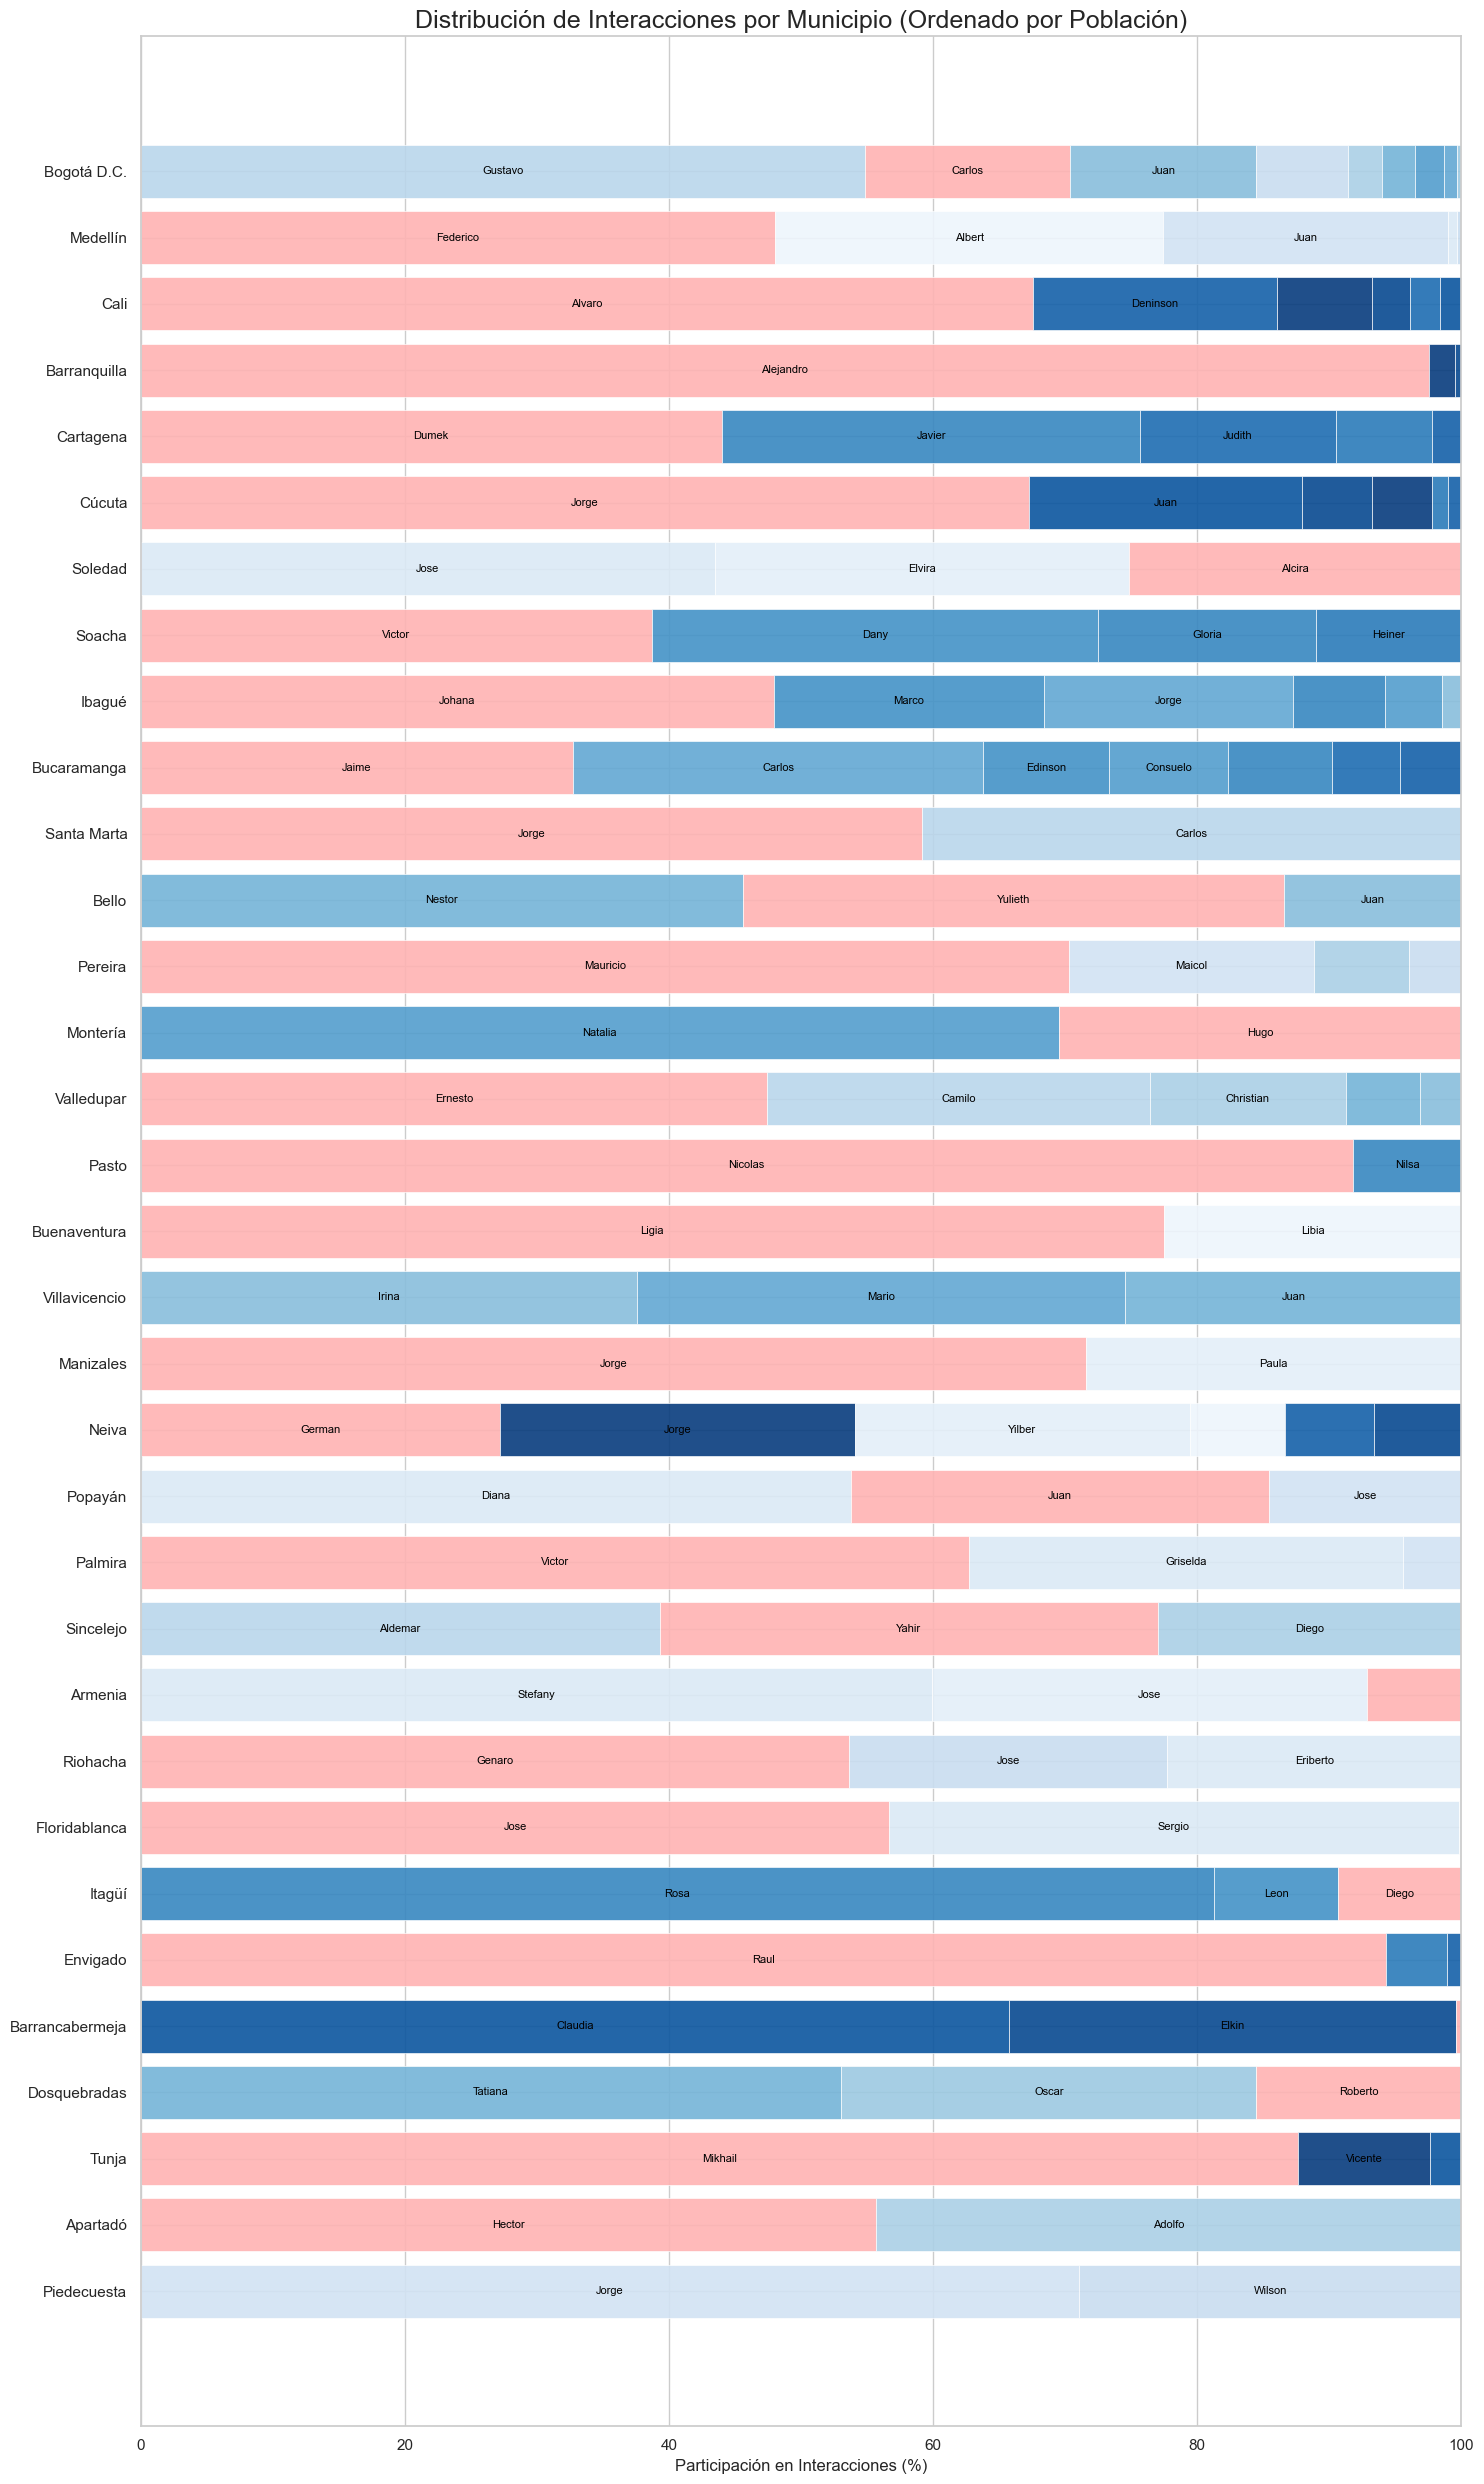

In [9]:
# 1. Cargar y Limpiar Población (Asegurando formato 05001)
df_poblacion = pd.read_excel(excel_path, sheet_name='Población 2023 (DANE)')
df_poblacion['DIVIPOLA'] = pd.to_numeric(df_poblacion['DIVIPOLA'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(5)

# 2. Preparar Candidatos (Extraer DIVIPOLA y calcular interacciones totales)
df_completo['DIVIPOLA'] = df_completo['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)
# Asegurarnos de que interacciones_totales esté calculada
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

# 3. Agrupar y Calcular Porcentajes
df_muni_stats = df_completo.groupby(['DIVIPOLA', 'Candidato', 'Ganador'])['interacciones_totales'].sum().reset_index()
totales_ciudad = df_muni_stats.groupby('DIVIPOLA')['interacciones_totales'].transform('sum')
df_muni_stats['porcentaje'] = (df_muni_stats['interacciones_totales'] / totales_ciudad) * 100

# 4. Obtener ranking de ciudades por población
ranking_ciudades = df_poblacion.sort_values(by='Población 2023', ascending=False)
ciudades_con_datos = df_muni_stats['DIVIPOLA'].unique()
ranking_filtrado = ranking_ciudades[ranking_ciudades['DIVIPOLA'].isin(ciudades_con_datos)]

# 5. Configuración de la Gráfica Nacional Pastel
fig, ax = plt.subplots(figsize=(15, 25))
competidor_palette = sns.color_palette("Blues", n_colors=20)
rojo_pastel = "#FFB3B3" # Rojo suave

for i, (idx, row_pop) in enumerate(ranking_filtrado.iterrows()):
    divi = row_pop['DIVIPOLA']
    nombre_muni = row_pop['Municipio']
    
    df_m = df_muni_stats[df_muni_stats['DIVIPOLA'] == divi].sort_values(by='porcentaje', ascending=False)
    
    left = 0
    for j, row in df_m.iterrows():
        color = rojo_pastel if row['Ganador'] == 'Sí' else competidor_palette[j % 20]
        
        ax.barh(nombre_muni, row['porcentaje'], left=left, color=color, 
                edgecolor='white', linewidth=0.5, alpha=0.9)
        
        # Etiqueta de nombre solo si el segmento es representativo (>8%)
        if row['porcentaje'] > 8:
            ax.text(left + row['porcentaje']/2, i, row['Candidato'].split()[0], 
                    va='center', ha='center', color='black', fontsize=8)
        left += row['porcentaje']

ax.set_title('Distribución de Interacciones por Municipio (Ordenado por Población)', fontsize=18)
ax.set_xlabel('Participación en Interacciones (%)')
ax.set_xlim(0, 100)
ax.invert_yaxis() 

plt.tight_layout()
plt.show()


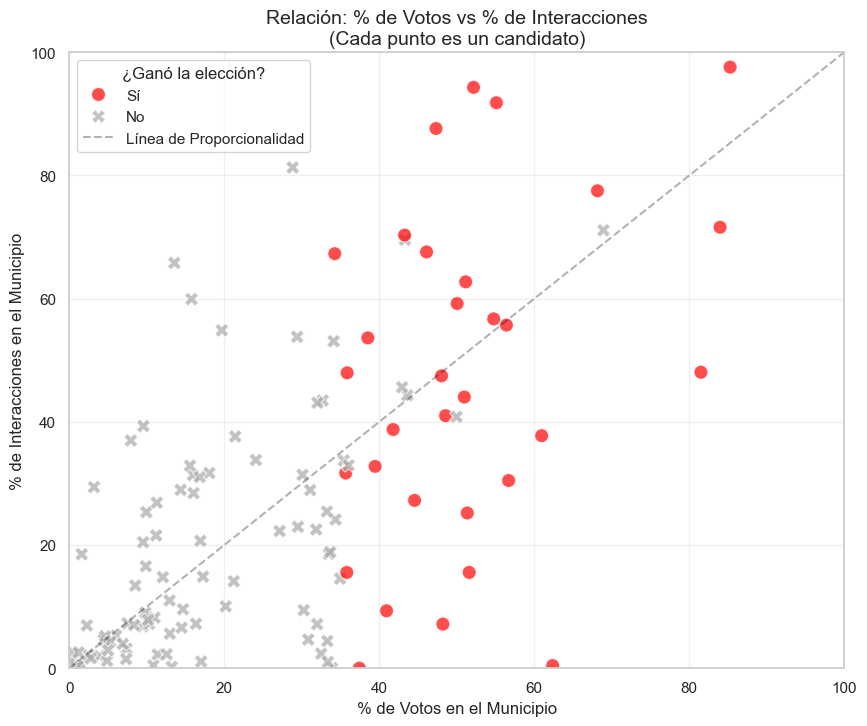

In [10]:
# 1. Preparar los datos agrupados por candidato y municipio
# Aseguramos que tenemos DIVIPOLA y votos en stats_candidato
stats_candidato['DIVIPOLA'] = stats_candidato['id_candidato'].str.split('-').str[1].str.zfill(5)

# 2. Calcular totales por municipio para sacar porcentajes
totales_muni = stats_candidato.groupby('DIVIPOLA').agg({
    'interacciones_totales': 'sum',
    'Votos': 'sum'
}).rename(columns={'interacciones_totales': 'total_interact_muni', 'Votos': 'total_votos_muni'})

# 3. Unir totales al dataframe de estadísticas
df_scatter = pd.merge(stats_candidato, totales_muni, on='DIVIPOLA', how='left')

# 4. Calcular los dos porcentajes (Ejes X e Y)
df_scatter['pct_votos'] = (df_scatter['Votos'] / df_scatter['total_votos_muni']) * 100
df_scatter['pct_interact'] = (df_scatter['interacciones_totales'] / df_scatter['total_interact_muni']) * 100

# 5. Graficar
plt.figure(figsize=(10, 8))

# Usamos scatterplot de seaborn para manejar el color por 'Ganador'
sns.scatterplot(
    data=df_scatter,
    x='pct_votos',
    y='pct_interact',
    hue='Ganador',
    palette={'Sí': '#FF0000', 'No': '#A9A9A9'}, # Rojo para ganador, Gris para el resto
    style='Ganador',
    s=100,
    alpha=0.7
)

# Añadir una línea de 45 grados para ver la "proporcionalidad"
plt.plot([0, 100], [0, 100], color='black', linestyle='--', alpha=0.3, label='Línea de Proporcionalidad')

plt.title('Relación: % de Votos vs % de Interacciones\n(Cada punto es un candidato)', fontsize=14)
plt.xlabel('% de Votos en el Municipio')
plt.ylabel('% de Interacciones en el Municipio')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(title='¿Ganó la elección?')
plt.grid(True, alpha=0.3)

plt.show()


In [11]:
# 1. Identificar al candidato con más interacciones por cada municipio
idx_max_interact = df_scatter.groupby('DIVIPOLA')['pct_interact'].idxmax()
lideres_redes = df_scatter.loc[idx_max_interact]

# 2. Contar en cuántos de esos casos el líder de redes es también el ganador
aciertos = lideres_redes[lideres_redes['Ganador'] == 'Sí']
total_municipios = len(lideres_redes)
num_aciertos = len(aciertos)

# 3. Calcular el porcentaje final
tasa_acierto = (num_aciertos / total_municipios) * 100

print(f"--- Análisis de Predicción (Redes vs Urnas) ---")
print(f"Total de municipios analizados: {total_municipios}")
print(f"Casos donde el líder de redes GANÓ: {num_aciertos}")
print(f"Tasa de Acierto: {tasa_acierto:.2f}%")


--- Análisis de Predicción (Redes vs Urnas) ---
Total de municipios analizados: 33
Casos donde el líder de redes GANÓ: 21
Tasa de Acierto: 63.64%


## **2. Análisis por interacciones promedio por post**

In [12]:
# 1. Calcular el promedio general de interacciones por candidato
df_promedios_cand = df_completo.groupby('Candidato')['interacciones_totales'].mean().reset_index()

# 2. Ordenar de mayor a menor y extraer los nombres de los 10 primeros
df_promedios_cand = df_promedios_cand.sort_values(by='interacciones_totales', ascending=False)
top_10_nombres_prom = df_promedios_cand.head(10)['Candidato'].tolist()

# 3. Filtrar el dataframe completo (que incluye la columna 'red_social' de cada post) 
# para quedarnos solo con las filas de esos 10 candidatos
df_top_10_prom = df_completo[df_completo['Candidato'].isin(top_10_nombres_prom)]


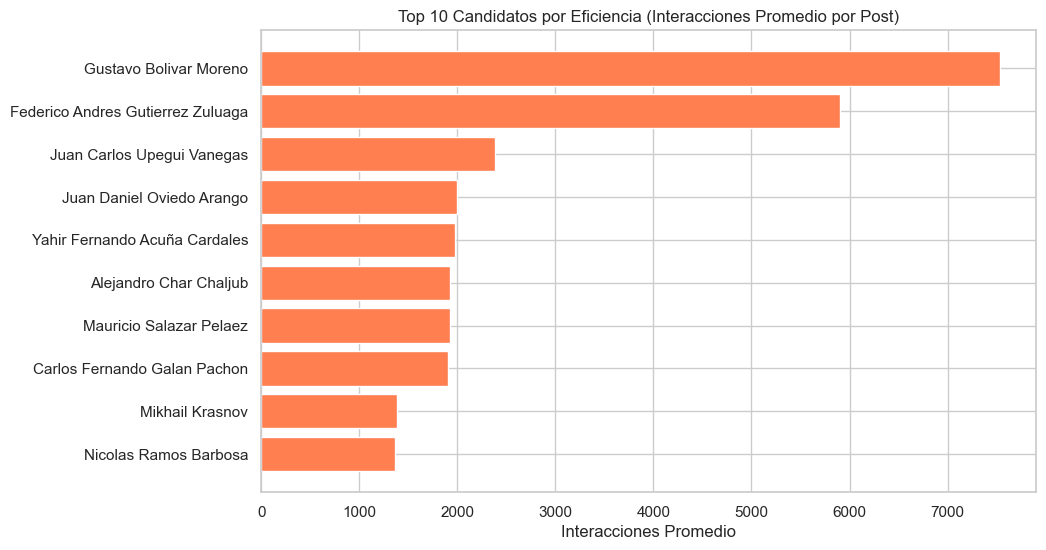

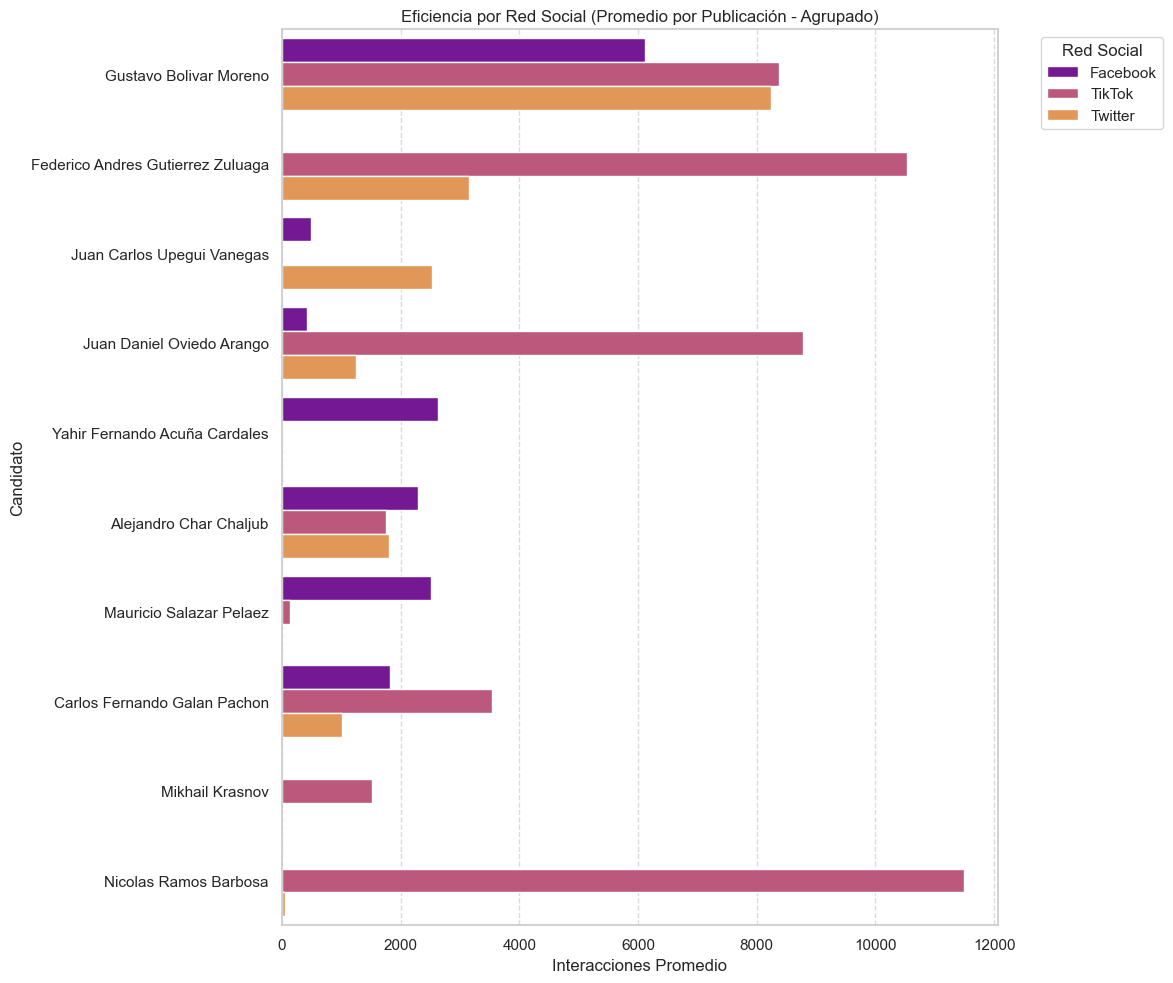

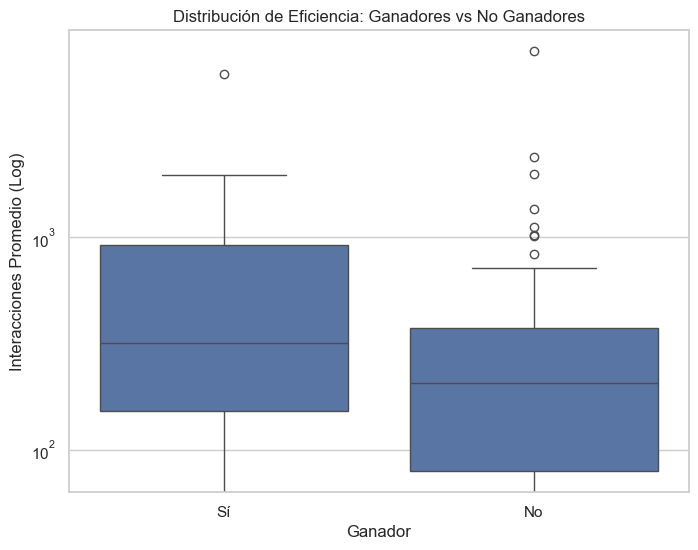


--- Prueba Mann-Whitney U para Interacciones Promedio ---
P-Valor: 0.0160
SIGNIFICATIVO AL 95%: La eficiencia de publicación sí distingue a los ganadores.


In [23]:
# 1. Asegurarnos de que tenemos la métrica de promedio por post en stats_candidato
stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# --- GRÁFICA 1: TOP 10 POR PROMEDIO ---
top_10_prom = stats_candidato.sort_values(by='interacciones_promedio', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_prom['Candidato'], top_10_prom['interacciones_promedio'], color='coral')
plt.title('Top 10 Candidatos por Eficiencia (Interacciones Promedio por Post)')
plt.xlabel('Interacciones Promedio')
plt.gca().invert_yaxis()
plt.show()

# --- GRÁFICA 2: TOP 10 POR RED SOCIAL (PROMEDIO) ---
# Usamos el mismo top 10 de nombres para filtrar
plt.figure(figsize=(12, 10))

# Usamos barplot de Seaborn que maneja las agrupaciones (hue) de forma nativa
sns.barplot(
    data=df_top_10_prom,
    y='Candidato',
    x='interacciones_totales',
    hue='red_social',
    estimator='mean',      # Importante: aquí le pedimos que calcule el promedio
    errorbar=None,         # Quitamos las líneas de error para que se vea más limpio
    order=top_10_nombres_prom, # Mantenemos el orden del Top 10
    palette='plasma'
)

plt.title('Eficiencia por Red Social (Promedio por Publicación - Agrupado)')
plt.xlabel('Interacciones Promedio')
plt.ylabel('Candidato')
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1. Calcular el promedio general de interacciones por candidato
df_promedios_cand = df_completo.groupby('Candidato')['interacciones_totales'].mean().reset_index()

# 2. Ordenar de mayor a menor y extraer los nombres de los 10 primeros
df_promedios_cand = df_promedios_cand.sort_values(by='interacciones_totales', ascending=False)
top_10_nombres_prom = df_promedios_cand.head(10)['Candidato'].tolist()

# 3. Filtrar el dataframe completo (que incluye la columna 'red_social' de cada post) 
# para quedarnos solo con las filas de esos 10 candidatos
df_top_10_prom = df_completo[df_completo['Candidato'].isin(top_10_nombres_prom)]

# --- GRÁFICA 3: BOXPLOT DE DISTRIBUCIÓN DE PROMEDIOS ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_promedio', data=stats_candidato)
plt.title('Distribución de Eficiencia: Ganadores vs No Ganadores')
plt.yscale('log')
plt.ylabel('Interacciones Promedio (Log)')
plt.show()

# --- PRUEBA DE HIPÓTESIS (90% CONFIANZA) ---
from scipy.stats import mannwhitneyu

ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_promedio']
no_ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_promedio']

stat_p, p_value_p = mannwhitneyu(ganadores_prom, no_ganadores_prom, alternative='two-sided')

print(f"\n--- Prueba Mann-Whitney U para Interacciones Promedio ---")
print(f"P-Valor: {p_value_p:.4f}")

if p_value_p < 0.05:
    print("SIGNIFICATIVO AL 95%: La eficiencia de publicación sí distingue a los ganadores.")
else:
    print("NO SIGNIFICATIVO: Ni siquiera la eficiencia por post garantiza la victoria.")



In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")

# Definición de rutas
base_path = r"c:\Users\juansoag\Downloads\Github\Avances_tesis\Herramientas"
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')

# Cargar datos
df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

# Calcular interacciones por publicación
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_redes['interacciones_totales'] = df_redes[interact_cols].sum(axis=1)
df_interacciones = df_redes.groupby('id_candidato')['interacciones_totales'].mean().reset_index()
df_interacciones.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Calcular el porcentaje del voto
# Votos totales por municipio
# Asegurar que Votos es numérico
df_electoral['Votos'] = pd.to_numeric(df_electoral['Votos'], errors='coerce')
votos_por_municipio = df_electoral.groupby('Municipio')['Votos'].sum().reset_index()
votos_por_municipio.rename(columns={'Votos': 'Votos_Totales'}, inplace=True)

df_electoral = df_electoral.merge(votos_por_municipio, on='Municipio', how='left')
df_electoral['porcentaje_voto'] = (df_electoral['Votos'] / df_electoral['Votos_Totales']) * 100

# Unir ambos dataframes
df_plot = df_interacciones.merge(df_electoral[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], on='id_candidato', how='inner')

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='interacciones_por_publicacion', y='porcentaje_voto', hue='Ganador', alpha=0.7)
plt.title('Relación entre Interacciones por Publicación y % del Voto')
plt.xlabel('Interacciones Promedio por Publicación (escala log)')
plt.ylabel('Porcentaje del Voto (%)')
plt.xscale('log') 
plt.tight_layout()
plt.savefig('scatter_test.png')
plt.close()

print(df_plot.head())


    id_candidato  interacciones_por_publicacion  \
0  COL-05001-001                    5906.018182   
1  COL-05001-004                       3.571429   
2  COL-05001-010                     720.123188   
3  COL-05001-011                      27.487500   
4  COL-05001-012                    2386.868852   

                            Candidato  porcentaje_voto Ganador  
0   Federico Andres Gutierrez Zuluaga        79.099509      Sí  
1        Rodolfo Andres Correa Vargas         1.213507      No  
2  Albert Yordano Corredor Bustamante         3.089699      No  
3      Maria Paulina Aguinaga Lezcano         1.454803      No  
4          Juan Carlos Upegui Vanegas        10.867158      No  


## **4. Análisis de Regresión Lineal (Interacciones vs % Votos)**
En esta sección se explora la relación entre las interacciones promedio por publicación y el porcentaje de voto obtenido.

In [15]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Limpiar columnas previas si existen para evitar colisiones
if 'Votos_Totales' in df_electoral.columns:
    df_electoral.drop(columns=['Votos_Totales'], inplace=True)
if 'porcentaje_voto' in df_electoral.columns:
    df_electoral.drop(columns=['porcentaje_voto'], inplace=True)


# Configuración de visualización
sns.set_theme(style="whitegrid")

# Usamos los DataFrames ya cargados en el entorno (df_redes, df_electoral)
# Calcular interacciones por publicación
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_redes['interacciones_totales'] = df_redes[interact_cols].sum(axis=1)
df_interacciones = df_redes.groupby('id_candidato')['interacciones_totales'].mean().reset_index()
df_interacciones.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Calcular el porcentaje del voto
# Asegurar que Votos es numérico
df_electoral['Votos'] = pd.to_numeric(df_electoral['Votos'], errors='coerce')
votos_por_municipio = df_electoral.groupby('Municipio')['Votos'].sum().reset_index()
votos_por_municipio.rename(columns={'Votos': 'Votos_Totales'}, inplace=True)

# Hacemos un merge temporal para el % de votos
df_electoral_plot = df_electoral.merge(votos_por_municipio, on='Municipio', how='left')
df_electoral_plot['porcentaje_voto'] = (df_electoral_plot['Votos'] / df_electoral_plot['Votos_Totales']) * 100

# Unir ambos dataframes
df_plot = df_interacciones.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)
df_plot = df_plot.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

### **Regresión con transformación logarítmica de interacciones**

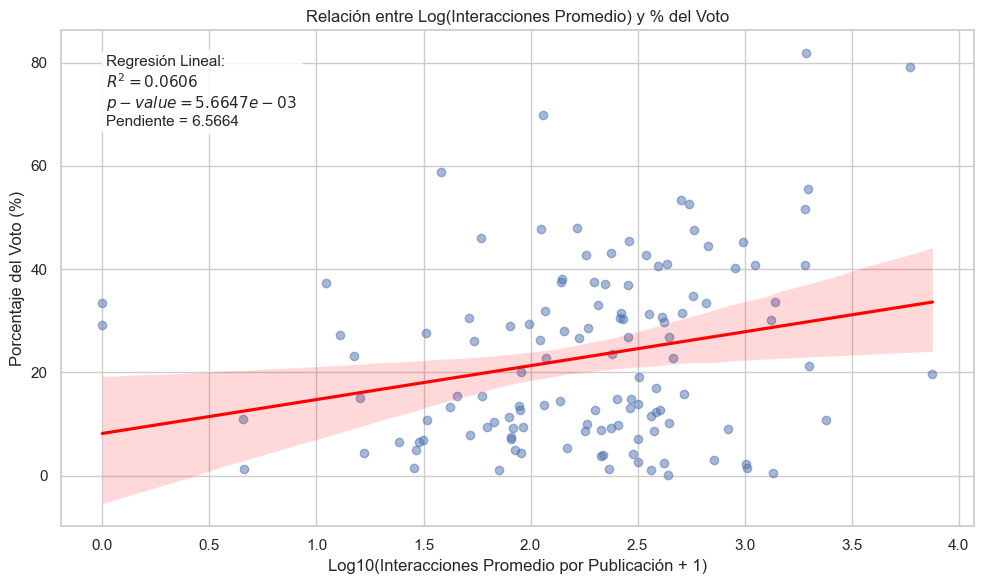

In [16]:
# Aplicar transformación logarítmica (se suma 1 para evitar log(0))
df_plot['log_interacciones'] = np.log10(df_plot['interacciones_por_publicacion'] + 1)

# Regresión lineal usando scipy.stats
x = df_plot['log_interacciones']
y = df_plot['porcentaje_voto']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Crear el gráfico
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_plot, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    scatter_kws={'alpha':0.5},
    line_kws={'color': 'red'}
)

plt.title('Relación entre Log(Interacciones Promedio) y % del Voto')
plt.xlabel('Log10(Interacciones Promedio por Publicación + 1)')
plt.ylabel('Porcentaje del Voto (%)')

# Añadir el texto con las métricas en la gráfica
metrics_text = (f'Regresión Lineal:\n'
                f'$R^2 = {r_squared:.4f}$\n'
                f'$p-value = {p_value:.4e}$\n'
                f'Pendiente = {slope:.4f}')

plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### **Regresión separada por Red Social**

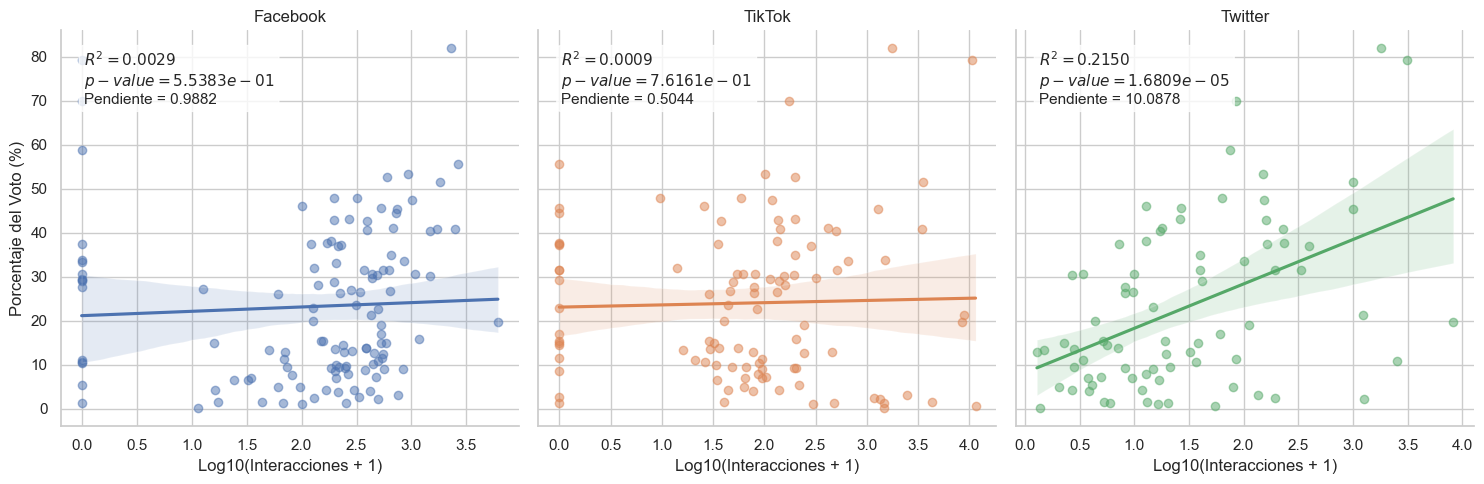

In [17]:
# Agrupar por id_candidato Y red_social para obtener el promedio por plataforma
df_interacciones_redes = df_redes.groupby(['id_candidato', 'red_social'])['interacciones_totales'].mean().reset_index()
df_interacciones_redes.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Unir dataframes
df_plot_redes = df_interacciones_redes.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)
df_plot_redes = df_plot_redes.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

# Aplicar transformación logarítmica
df_plot_redes['log_interacciones'] = np.log10(df_plot_redes['interacciones_por_publicacion'] + 1)

# Crear lmplot para múltiples paneles divididos por 'red_social'
g = sns.lmplot(
    data=df_plot_redes, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    col='red_social', 
    hue='red_social',
    scatter_kws={'alpha': 0.5},
    facet_kws={'sharex': False, 'sharey': True},
    height=5, 
    aspect=1
)

g.set_axis_labels('Log10(Interacciones + 1)', 'Porcentaje del Voto (%)')
g.set_titles(col_template="{col_name}")

# Calcular y añadir las métricas de regresión en cada subgráfico
for ax, red in zip(g.axes.flat, g.col_names):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    
    if len(data_red) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(data_red['log_interacciones'], data_red['porcentaje_voto'])
        metrics_text = (f'$R^2 = {r_value**2:.4f}$\n'
                        f'$p-value = {p_value:.4e}$\n'
                        f'Pendiente = {slope:.4f}')
        
        ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

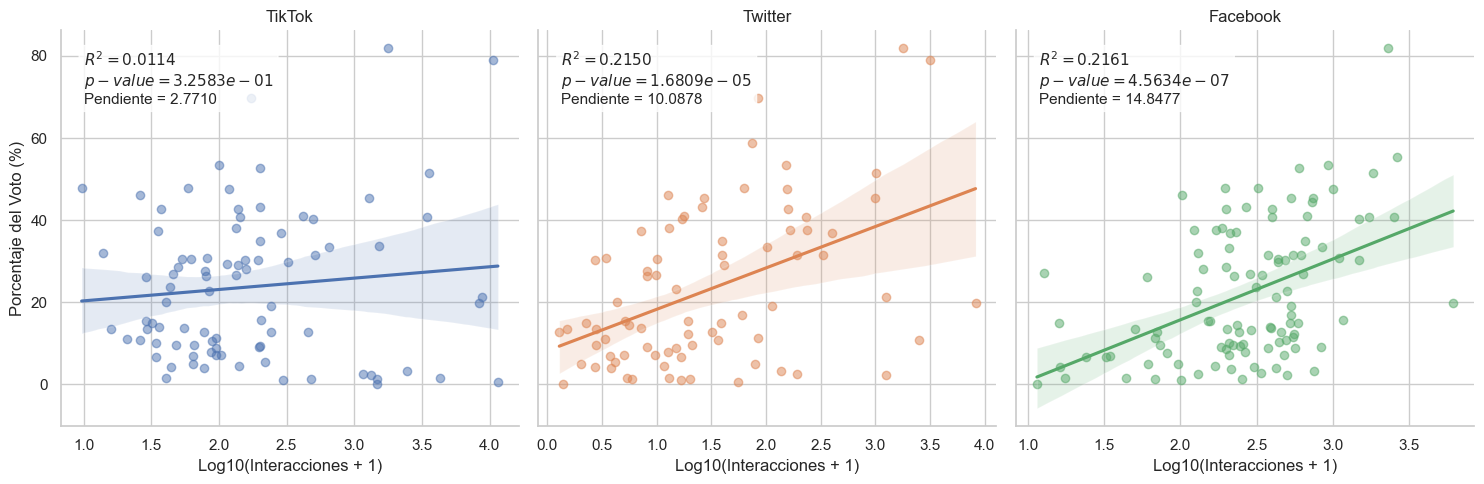

In [18]:
# Agrupar por id_candidato Y red_social para obtener el promedio por plataforma
df_interacciones_redes = df_redes.groupby(['id_candidato', 'red_social'])['interacciones_totales'].mean().reset_index()
df_interacciones_redes.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Unir dataframes
df_plot_redes = df_interacciones_redes.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)

# 1. Eliminar filas con valores NaN (nulos)
df_plot_redes = df_plot_redes.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

# 2. NUEVO: Eliminar a los candidatos que tienen 0 interacciones en la red social
df_plot_redes = df_plot_redes[df_plot_redes['interacciones_por_publicacion'] > 0].copy()

# Aplicar transformación logarítmica (ya no es estrictamente necesario el +1 porque no hay ceros, 
# pero lo dejamos para mantener la misma escala gráfica de antes)
df_plot_redes['log_interacciones'] = np.log10(df_plot_redes['interacciones_por_publicacion'] + 1)

# Crear lmplot para múltiples paneles divididos por 'red_social'
g = sns.lmplot(
    data=df_plot_redes, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    col='red_social', 
    hue='red_social',
    scatter_kws={'alpha': 0.5},
    facet_kws={'sharex': False, 'sharey': True},
    height=5, 
    aspect=1
)

g.set_axis_labels('Log10(Interacciones + 1)', 'Porcentaje del Voto (%)')
g.set_titles(col_template="{col_name}")

# Calcular y añadir las métricas de regresión en cada subgráfico
for ax, red in zip(g.axes.flat, g.col_names):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    
    if len(data_red) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(data_red['log_interacciones'], data_red['porcentaje_voto'])
        metrics_text = (f'$R^2 = {r_value**2:.4f}$\n'
                        f'$p-value = {p_value:.4e}$\n'
                        f'Pendiente = {slope:.4f}')
        
        ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [19]:
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score

for red in df_plot_redes['red_social'].unique():
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    X = data_red[['log_interacciones']]
    y = data_red['porcentaje_voto']
    
    model = HuberRegressor()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))
    print(f"{red}: R² Huber = {r2:.4f}")


TikTok: R² Huber = -0.0034
Twitter: R² Huber = 0.2128
Facebook: R² Huber = 0.2109


Los resultados del modelo de regresión de Huber muestran que las interacciones en Facebook y Twitter explican aproximadamente el 21% de la varianza en el porcentaje de voto obtenido (R² ≈ 0.21, p < 0.01), y este resultado es robusto ante la presencia de valores atípicos. En contraste, TikTok no muestra ninguna relación estadísticamente significativa (R² = -0.003), lo que sugiere que la dinámica de esta plataforma —basada en la viralidad algorítmica más que en la base de seguidores— la convierte en un predictor poco confiable del desempeño electoral en el contexto de elecciones de alcaldía colombianas

In [20]:
from scipy.stats import spearmanr
import pandas as pd

# Calcular correlación de Spearman por red social
resultados_spearman = []

for red in df_plot_redes['red_social'].unique():
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    rho, p = spearmanr(data_red['log_interacciones'], data_red['porcentaje_voto'])
    resultados_spearman.append({
        'Red Social': red,
        'ρ Spearman': round(rho, 4),
        'p-value': f'{p:.4e}',
        'Significativo (p<0.05)': '✅' if p < 0.05 else '❌',
        'n': len(data_red)
    })

df_spearman = pd.DataFrame(resultados_spearman).sort_values('ρ Spearman', ascending=False)
print(df_spearman.to_string(index=False))


Red Social  ρ Spearman    p-value Significativo (p<0.05)   n
  Facebook      0.4394 2.1862e-06                      ✅ 107
   Twitter      0.4249 9.5099e-05                      ✅  79
    TikTok      0.0207 8.4917e-01                      ❌  87


Para evaluar la robustez de los resultados, se aplicaron tres métodos complementarios: regresión lineal por mínimos cuadrados ordinarios (OLS), regresión de Huber (robusta ante valores atípicos) y correlación de Spearman (no paramétrica). Los tres métodos convergen en el mismo hallazgo: en Facebook y Twitter, las interacciones promedio por publicación —transformadas logarítmicamente— presentan una asociación positiva, moderada y estadísticamente significativa con el porcentaje de voto obtenido por los candidatos (ρ ≈ 0.44, p < 0.001; R² ≈ 0.21). TikTok, en contraste, no muestra ninguna asociación relevante bajo ninguno de los tres enfoques (ρ = 0.021, p = 0.85), lo que sugiere que la dinámica algorítmica de esa plataforma desvincula las interacciones del apoyo electoral efectivo.

C:\Users\juansoag\AppData\Local\Temp\ipykernel_18064\503450398.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juansoag\AppData\Local\Temp\ipykernel_18064\503450398.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


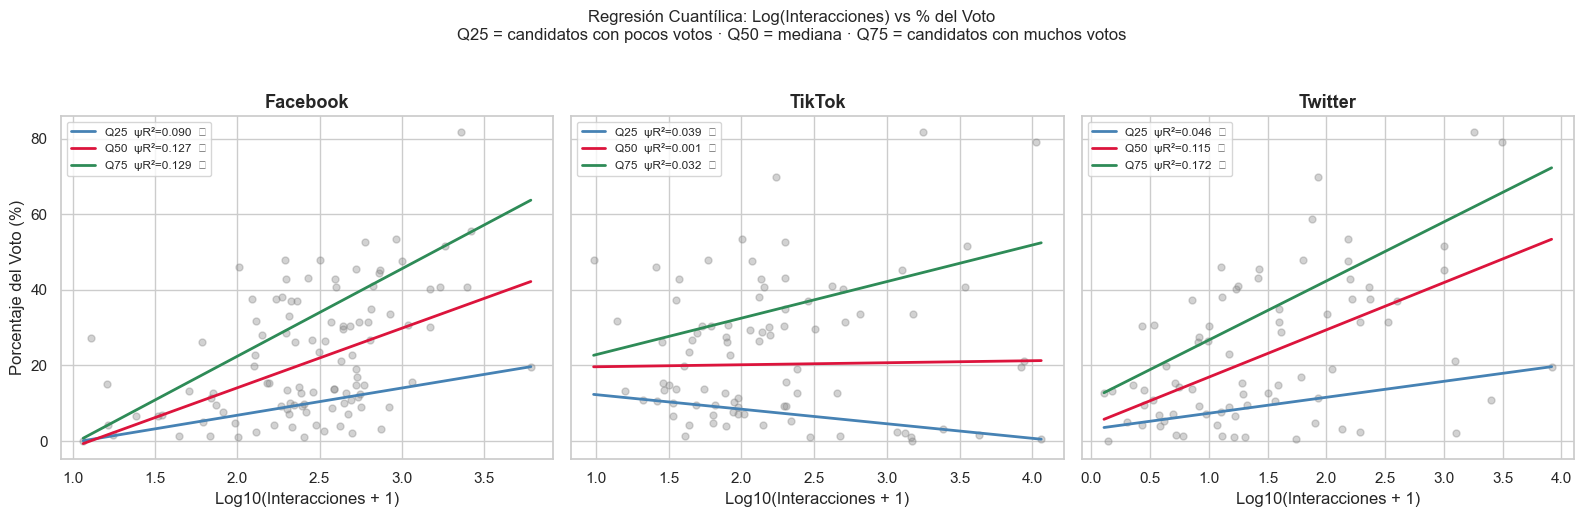


── Resultados Regresión Cuantílica ──────────────────────────────────
Red Social Cuantil  Pendiente  Intercepto  Pseudo R²    p-value Significativo   n
  Facebook     Q25     7.1853     -7.5275     0.0900 1.9550e-02             ✅ 107
  Facebook     Q50    15.7230    -17.3345     0.1269 3.6464e-04             ✅ 107
  Facebook     Q75    23.0973    -23.7366     0.1286 1.8221e-06             ✅ 107
    TikTok     Q25    -3.8533     16.1418     0.0394 2.8422e-01             ❌  87
    TikTok     Q50     0.5335     19.1195     0.0005 8.9499e-01             ❌  87
    TikTok     Q75     9.6750     13.1538     0.0322 2.5988e-02             ✅  87
   Twitter     Q25     4.2257      3.1284     0.0457 1.8714e-01             ❌  79
   Twitter     Q50    12.5074      4.3929     0.1152 9.1080e-05             ✅  79
   Twitter     Q75    15.6256     11.0832     0.1725 3.2062e-06             ✅  79


In [21]:
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

quantiles = [0.25, 0.50, 0.75]
colores   = {0.25: 'steelblue', 0.50: 'crimson', 0.75: 'seagreen'}
redes     = sorted(df_plot_redes['red_social'].unique())

fig, axes = plt.subplots(1, len(redes), figsize=(16, 5), sharey=True)

resultados_qr = []

for ax, red in zip(axes, redes):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red].copy()

    # Scatter de fondo
    ax.scatter(data_red['log_interacciones'], data_red['porcentaje_voto'],
               alpha=0.35, color='gray', s=25, label='_nolegend_')

    x_range = np.linspace(data_red['log_interacciones'].min(),
                          data_red['log_interacciones'].max(), 200)

    for q in quantiles:
        res = smf.quantreg('porcentaje_voto ~ log_interacciones', data_red).fit(q=q)

        y_pred = res.params['Intercept'] + res.params['log_interacciones'] * x_range
        pseudo_r2 = res.prsquared
        p_val     = res.pvalues['log_interacciones']
        sig       = '✅' if p_val < 0.05 else '❌'

        ax.plot(x_range, y_pred, color=colores[q], linewidth=2,
                label=f'Q{int(q*100)}  ψR²={pseudo_r2:.3f}  {sig}')

        resultados_qr.append({
            'Red Social'  : red,
            'Cuantil'     : f'Q{int(q*100)}',
            'Pendiente'   : round(res.params['log_interacciones'], 4),
            'Intercepto'  : round(res.params['Intercept'], 4),
            'Pseudo R²'   : round(pseudo_r2, 4),
            'p-value'     : f'{p_val:.4e}',
            'Significativo': sig,
            'n'           : len(data_red)
        })

    ax.set_title(red, fontsize=13, fontweight='bold')
    ax.set_xlabel('Log10(Interacciones + 1)')
    ax.legend(fontsize=8.5, loc='upper left')

axes[0].set_ylabel('Porcentaje del Voto (%)')
fig.suptitle('Regresión Cuantílica: Log(Interacciones) vs % del Voto\n'
             'Q25 = candidatos con pocos votos · Q50 = mediana · Q75 = candidatos con muchos votos',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

# ── Tabla de resultados ───────────────────────────────────────────────────────
df_qr = pd.DataFrame(resultados_qr)
print("\n── Resultados Regresión Cuantílica ──────────────────────────────────")
print(df_qr.to_string(index=False))


"La regresión cuantílica revela un patrón consistente a través de las tres plataformas analizadas: la pendiente de la relación entre el logaritmo de interacciones promedio por publicación y el porcentaje de voto aumenta sistemáticamente con el cuantil (Q25 < Q50 < Q75), lo que indica que el efecto de la presencia digital no es homogéneo, sino que opera como un mecanismo amplificador de las ventajas electorales existentes. Facebook es la única plataforma donde la relación es estadísticamente significativa incluso en el cuartil inferior (β=7.19, p=0.020), sugiriendo que tiene un alcance más democrático en términos electorales. Twitter y TikTok, en contraste, solo muestran asociaciones significativas en los cuantiles superiores (Q50 y Q75), lo que indica que estas plataformas benefician predominantemente a candidatos que ya parten de una posición competitiva. El caso de TikTok es particularmente notable: la pendiente en Q25 es negativa (β=-4.17, p=0.24), y el pseudo R² en Q50 es prácticamente nulo (ψR²=0.001), lo que sugiere que la viralidad algorítmica de esta plataforma desvincula las interacciones digitales del apoyo electoral efectivo para la mayoría de candidatos."